# CIFAR-10 Project (Part 2) - Model Improvements

The goal of this notebook is to improve the baseline CNN model from `01_cifar10_baseline`

In this notebook:  
- Add data augmentation
- Add Batch Normalization
- Add Dropout
- Use callbacks (EarlyStopping, ReduceLROnPlateau)
- Improve validation and test accuracy

Next step:  
`03_error_analysis` - analyze model mistakes in detail

## Data Preparation (Reused from Baseline)

This section follows the exact same data preparation pipeline as in `01_cifar10_baseline`:  
- Load CIFAR-10
- Normalize pixel values
- Create train / validation split
- Inspect sample images
  
Keeping the data pipeline identical ensures that performance improvements come only from architectural and training changes

In [3]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix
from pathlib import Path

RESULTS = Path("../results")
RESULTS.mkdir(parents = True, exist_ok = True)
RESULTS

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("train:", X_train.shape, y_train.shape)
print("test:", X_test.shape, y_test.shape)

train: (50000, 32, 32, 3) (50000, 1)
test: (10000, 32, 32, 3) (10000, 1)


C:\Users\lb_20\Desktop\Projects\cnn_generalization_project\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


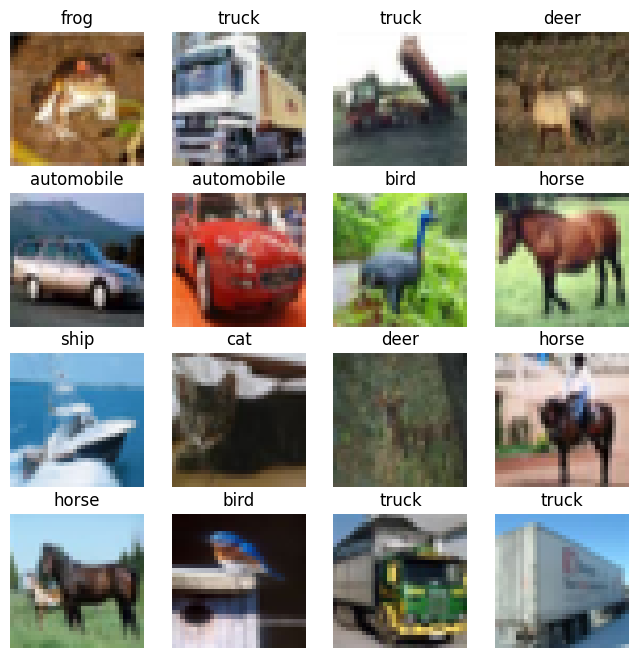

In [4]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

plt.figure(figsize = (8,8))

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())

0.0 1.0


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.1, random_state = 0, stratify = y_train)

print("train:", X_train.shape)
print("validation:", X_val.shape)
print("test:", X_test.shape)

train: (45000, 32, 32, 3)
validation: (5000, 32, 32, 3)
test: (10000, 32, 32, 3)


## Data Augmentation / Improved CNN Architecture

Random transformations:  
- Horizontal flip
- Rotation
- Zoom

This helps the model:  
- Generalize better
- Learn more robust features

Compared to the baseline model, this version adds:  
- Data augmentation layer
- Batch Normalization
- More convolution blocks
- Dropout layers
- Global Average Pooling

These changes help:  
- Reduce overfitting
- Improve generalization

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name = "augmentation")

model2 = models.Sequential([
    layers.Input(shape = (32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), padding = "same", activation = "relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding = "same", activation = "relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding = "same", activation = "relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding = "same", activation = "relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding = "same", activation = "relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation = "softmax")])

model2.summary()

model2.save(RESULTS / "improved_model.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)            │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 158,506 (619.16 KB)

 Trainable params: 157,866 (616.66 KB)

 Non-trainable params: 640 (2.50 KB)

## Compile and Train the Model

I use:  
- Optimizer: Adam (learning rate = 0.001)
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy

Callbacks:  
- EarlyStopping (stop training when no improvement)
- ReduceLROnPlateau (reduce learning rate when validation stalls)

Training runs up to 40 epochs

In [10]:
model2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"])

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor = "val_accuracy",
        patience = 5,
        restore_best_weights = True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = "val_accuracy",
        factor = 0.5,
        patience = 2,
        min_lr = 1e-6)]

history2 = model2.fit(X_train, y_train, 
                      epochs = 40, 
                      batch_size = 64,
                      validation_data = (X_val, y_val),
                      callbacks = callbacks)

pd.DataFrame(history2.history).to_csv(RESULTS / "improved_history.csv", index = False)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.4341 - loss: 1.5552 - val_accuracy: 0.4896 - val_loss: 1.4341 - learning_rate: 0.0010
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.5641 - loss: 1.2285 - val_accuracy: 0.5742 - val_loss: 1.2040 - learning_rate: 0.0010
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.6140 - loss: 1.0936 - val_accuracy: 0.5802 - val_loss: 1.2537 - learning_rate: 0.0010
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6455 - loss: 1.0099 - val_accuracy: 0.6674 - val_loss: 0.9474 - learning_rate: 0.0010
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.6733 - loss: 0.9434 - val_accuracy: 0.6726 - val_loss: 0.9553 - learning_rate: 0.0010
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.6895 - loss: 0.8954 - val_accuracy: 0.7178 - val_loss: 0.8098 - learning_rate: 0.0010
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.7043 - l

## Training Curves

The plot shows:
- Training vs Validation Loss
- Training vs Validation Accuracy

This helps check:  
- Overfitting
- Training stability
- Learning progress

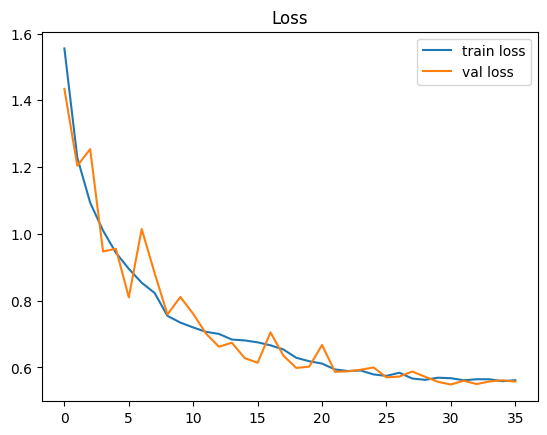

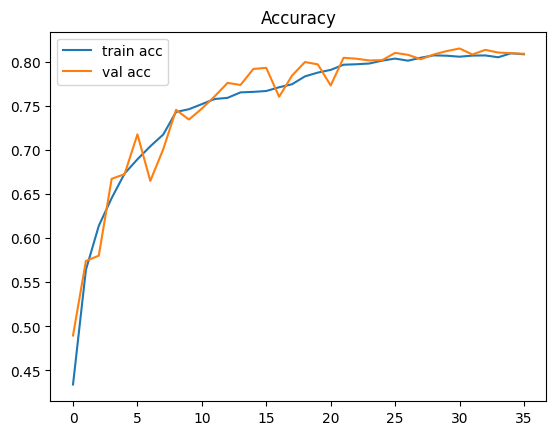

In [12]:
hist = pd.DataFrame(history2.history)

plt.figure()
plt.plot(hist["loss"], label = "train loss")
plt.plot(hist["val_loss"], label = "val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(hist["accuracy"], label = "train acc")
plt.plot(hist["val_accuracy"], label = "val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

## Evaluate on Test Set

The improved model was evaluated on the test dataset   

Was recorded:   
- Best validation accuracy
- Final test accuracy

This shows model generalization

In [14]:
test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose = 0)
print("final val_accuracy =", max(history2.history["val_accuracy"]))
print("test accuracy =", test_acc2)

with open(RESULTS / "improved_metrics.txt","w") as f:
    f.write(f"test_accuracy = {test_acc2}\n")
    f.write(f"best_val_accuracy = {max(history2.history['val_accuracy'])}\n")

final val_accuracy = 0.8151999711990356
test accuracy = 0.8154000043869019


## Create Inference Model

The data augmentation layer was removed  
This creates a clean model for inference only  
The inference model is saved separately  

In [16]:
inference_model = models.Sequential(
    [layer for layer in model2.layers if layer.name != "augmentation"],
    name = "improved_inference")

inference_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"])

test_loss_inf, test_acc_inf = inference_model.evaluate(X_test, y_test, verbose = 0)
print("Inference test accuracy:", test_acc_inf)

Inference test accuracy: 0.8154000043869019


In [17]:
inference_model.save(RESULTS / "improved_model_inference.keras")
print("Saved:", (RESULTS / "improved_model_inference.keras").resolve())

Saved: C:\Users\lb_20\Desktop\Projects\cnn_generalization_project\results\improved_model_inference.keras


## Confusion Matrix (Improved Model)

The confusion matrix was computed for test predictions

This helps to:  
- Compare with baseline
- Identify class-level improvements
- Prepare for detailed error analysis

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


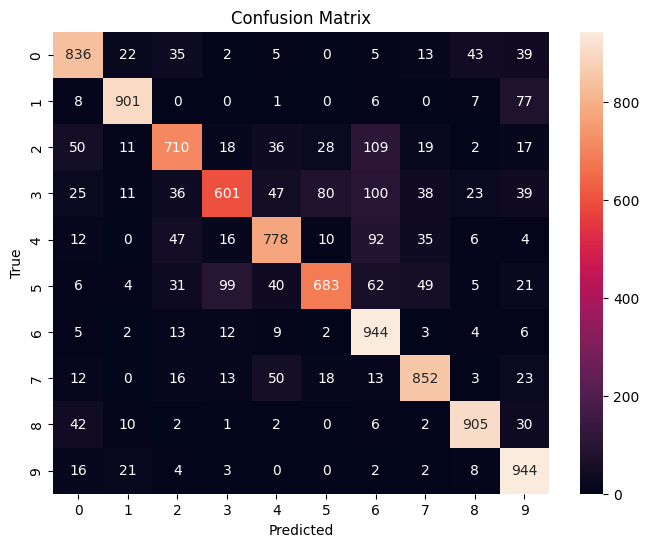

In [19]:
y_pred2 = model2.predict(X_test)
y_pred_classes2 = y_pred2.argmax(axis = 1)

cm2 = confusion_matrix(y_test, y_pred_classes2)

plt.figure(figsize = (8,6))
sns.heatmap(cm2, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(RESULTS / "improved_confusion_matrix.png")
plt.show()

## Improved Model Summary

Test Accuracy: ~0.81-0.82  

Improvements compared to baseline:
- Higher validation accuracy
- Better generalization
- Reduced overfitting
- More stable training

Next Step:  
Analyze model errors in `03_error_analysis`